In [46]:

import pandas as pd
import numpy as np
from functools import reduce
from itertools import combinations
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
import scipy.stats as stats


In [40]:
df = pd.read_csv("data/merged_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.dropna()


=== Projekt: Zmienność kursu dollara w złotówkach ===

Zestaw danych zawiera 1849 obserwacji x 10 zmiennych i daty jako index

Lista dostępnych zmiennych: ['CL=F', 'EURUSD=X', 'GC=F', 'PLN=X', '^GSPC', '^VIX', 'une_rt_m', 'T10Y2Y', 'TRESEGUSM052N', 'TRESEGPLM052N']

Statystyki: 
                 CL=F  EURUSD=X         GC=F     PLN=X        ^GSPC       ^VIX  \
mean       69.349470  1.116401  2088.270904  4.016626  4371.494753  21.536095   
median     70.300003  1.110494  1878.199951  3.957990  4233.450195  19.430000   
std        18.095260  0.053050   662.880745  0.283985  1121.613731   8.559494   
min        13.690000  0.967006  1269.800049  3.583850  2300.729980  11.790000   
max       130.500000  1.235025  4556.299805  5.058050  6945.770020  85.470001   
kurtosis    0.703518 -0.336024     2.246971  1.195344    -0.635447  12.832752   
skew        0.068422 -0.005177     1.611969  1.159858     0.450106   2.778144   

          une_rt_m    T10Y2Y  TRESEGUSM052N  TRESEGPLM052N  
mean     

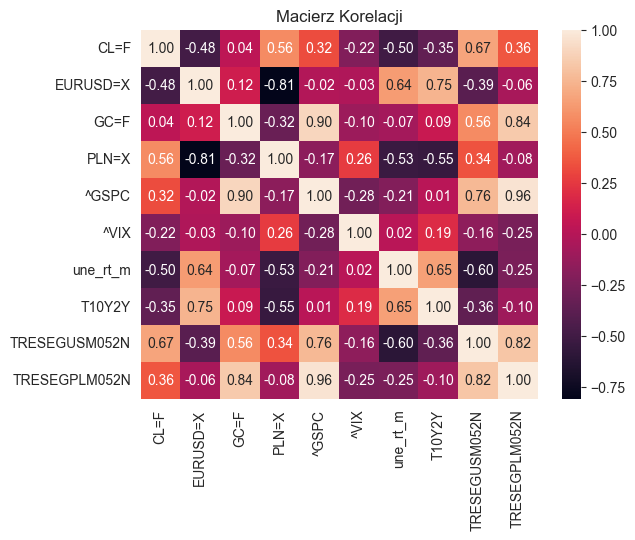

In [41]:
print("=== Projekt: Zmienność kursu dollara w złotówkach ===\n")

rows, columns = df.shape
print(f"Zestaw danych zawiera {rows} obserwacji x {columns} zmiennych i daty jako index\n")
print(f"Lista dostępnych zmiennych: {df.columns.values.tolist()}\n")

stats = df.agg(['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skew'])
print(f"Statystyki: \n {stats}\n")

fig, ax = plt.subplots()
sns.heatmap(data=df.corr(), annot=True, fmt=".2f", ax=ax)
ax.set_title("Macierz Korelacji")
plt.show()

In [42]:
numeric_data = df.select_dtypes(include=[np.number])
feature_cols = [c for c in numeric_data.columns if c != "PLN=X"]

corr_matrix = numeric_data.corr()
print(corr_matrix)

R0 = corr_matrix.iloc[1:len(feature_cols)+1, 0]
R = corr_matrix.iloc[1:len(feature_cols)+1, 1:len(feature_cols)+1]

n_vars = len(feature_cols)

best_H = -np.inf
best_combo = []

for r in range(1, n_vars+1):
    for combo in combinations(range(n_vars), r):
        k = list(combo)
        H=0
        for i in k:
            mianownik = sum(abs(R.iloc[i, j]) for j in k)
            if mianownik > 0:
                H += R0.iloc[i]**2/mianownik
        if H > best_H:
            best_H = H
            best_combo = [feature_cols[i] for i in k]

print(f"\n Z metody Hellwiga optymalny zestaw zmiennych objasniajacych: {best_combo}")

                   CL=F  EURUSD=X      GC=F     PLN=X     ^GSPC      ^VIX  \
CL=F           1.000000 -0.484715  0.035113  0.562346  0.322976 -0.220309   
EURUSD=X      -0.484715  1.000000  0.115731 -0.809745 -0.016524 -0.029099   
GC=F           0.035113  0.115731  1.000000 -0.315038  0.896957 -0.104744   
PLN=X          0.562346 -0.809745 -0.315038  1.000000 -0.173360  0.259015   
^GSPC          0.322976 -0.016524  0.896957 -0.173360  1.000000 -0.280286   
^VIX          -0.220309 -0.029099 -0.104744  0.259015 -0.280286  1.000000   
une_rt_m      -0.501476  0.637205 -0.073291 -0.530563 -0.214252  0.016067   
T10Y2Y        -0.350395  0.745381  0.085164 -0.545636  0.010444  0.190581   
TRESEGUSM052N  0.674125 -0.386144  0.563942  0.344191  0.762502 -0.161193   
TRESEGPLM052N  0.363453 -0.056088  0.837676 -0.084364  0.958499 -0.253527   

               une_rt_m    T10Y2Y  TRESEGUSM052N  TRESEGPLM052N  
CL=F          -0.501476 -0.350395       0.674125       0.363453  
EURUSD=X       0.637

In [47]:
def test_summary(model):
    r = model.resid

    # Normalność Reszt
    statistic, p = stats.shapiro(r)
    print(f'\nShapiro-Wilk (normalność reszt):')
    print(f'  W={statistic:.4f}, p={p:.4f}  {"normlanosc" if p > 0.05 else "brak normalności"}')

    x, bp_p, y, z = het_breuschpagan(r, model.model.exog)
    print(f'\nBreusch-Pagan (heteroskedastyczność):')
    print(f'  p={bp_p:.4f}  {"homoskedastyczność" if bp_p > 0.05 else "heteroskedastyczność!"}')

    # Postać liniowa (RESET)
    reset_res = linear_reset(model, power=2, use_f=True)
    print(f'\nRESET (postać liniowa):')
    print(f'  p={reset_res.pvalue:.4f}  {"postac liniowa" if reset_res.pvalue > 0.05 else "zła postać modelu!"}')


    # Autokorelacja (test serii)
    dw = durbin_watson(r)
    print(f'\nDurbin-Watson: {dw:.4f}  (idealnie ~2.0)')
    print('=' * 55)

model = smf.ols('Q("PLN=X") ~ Q("CL=F") + Q("EURUSD=X") + Q("GC=F") + Q("^GSPC") + Q("^VIX") + Q("une_rt_m") + Q("T10Y2Y") + Q("TRESEGUSM052N") + Q("TRESEGPLM052N")', data=df).fit()
print(model.summary())
test_summary(model)

model = smf.ols(
    'Q("PLN=X") ~ Q("GC=F") + Q("TRESEGUSM052N")',
    data=df).fit()
print(model.summary())
test_summary(model)

                            OLS Regression Results                            
Dep. Variable:             Q("PLN=X")   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     1336.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:34:40   Log-Likelihood:                 1572.0
No. Observations:                1849   AIC:                            -3124.
Df Residuals:                    1839   BIC:                            -3069.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              7.5507      0

In [30]:
idx = np.random.permutation(len(df))
data_r = df.iloc[idx].reset_index(drop=True)

train = data_r.iloc[:1500].copy()
test = data_r.iloc[1500:].copy()

model = smf.ols(
    'Q("PLN=X") ~ Q("CL=F") + Q("EURUSD=X") + Q("GC=F") + Q("^GSPC") + Q("^VIX") + Q("une_rt_m") + Q("T10Y2Y") + Q("TRESEGUSM052N") + Q("TRESEGPLM052N")',
    data=df).fit()

p_fit = model.predict(test)
e = test['PLN=X'] - p_fit

MAE = np.mean(np.abs(e))
RMSE = np.sqrt(np.mean(e ** 2))
MAPE = np.mean(np.abs(e / test['PLN=X'])) * 100

print(f'MAE:  {MAE:.2f}')
print(f'RMSE: {RMSE:.2f}')
print(f'MAPE: {MAPE:.2f}%')

MAE:  0.08
RMSE: 0.10
MAPE: 2.09%
